# Kalo's 
## Exercise 1.4 Hotdog -- no hotdog 
This is the poster hand-in project for the course. Please see the associated PDF for instructions.

In [1]:
import os
import numpy as np
import glob
import PIL.Image as Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

We always check that we are running on a GPU

In [2]:
if torch.cuda.is_available():
    print("The code will run on GPU.")
else:
    print("The code will run on CPU. Go to Edit->Notebook Settings and choose GPU as the hardware accelerator")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

The code will run on CPU. Go to Edit->Notebook Settings and choose GPU as the hardware accelerator


We provide you with a class that can load the *hotdog/not hotdog* dataset you should use from /dtu/datasets1/02516/

In [3]:
class Hotdog_NotHotdog(torch.utils.data.Dataset):
    def __init__(self, train, transform, data_path='hotdog_nothotdog'):
        'Initialization'
        self.transform = transform
        data_path = os.path.join(data_path, 'train' if train else 'test')
        image_classes = [os.path.split(d)[1] for d in glob.glob(data_path +'/*') if os.path.isdir(d)]
        image_classes.sort()
        self.name_to_label = {c: id for id, c in enumerate(image_classes)}
        self.image_paths = glob.glob(data_path + '/*/*.jpg')
        
    def __len__(self):
        'Returns the total number of samples'
        return len(self.image_paths)

    def __getitem__(self, idx):
        'Generates one sample of data'
        image_path = self.image_paths[idx]
        
        image = Image.open(image_path)
        c = os.path.split(os.path.split(image_path)[0])[1]
        y = self.name_to_label[c]
        X = self.transform(image)
        return X, y

Below is the simple way of converting the images to something that can be fed through a network.
Feel free to use something other than $128\times128$ images.

In [4]:
size = 128

# Hypothesis 2: Standard ImageNet Channel Normalization (centers input to mean ~0, std ~1)
norm_mean = [0.485, 0.456, 0.406]
norm_std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((size, size)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=norm_mean, std=norm_std)
])

test_transform = transforms.Compose([
    transforms.Resize((size, size)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=norm_mean, std=norm_std)
])

batch_size = 64
trainset = Hotdog_NotHotdog(train=True, transform=train_transform)
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=0)
testset = Hotdog_NotHotdog(train=False, transform=test_transform)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=0)


Let's look at some images from our data 

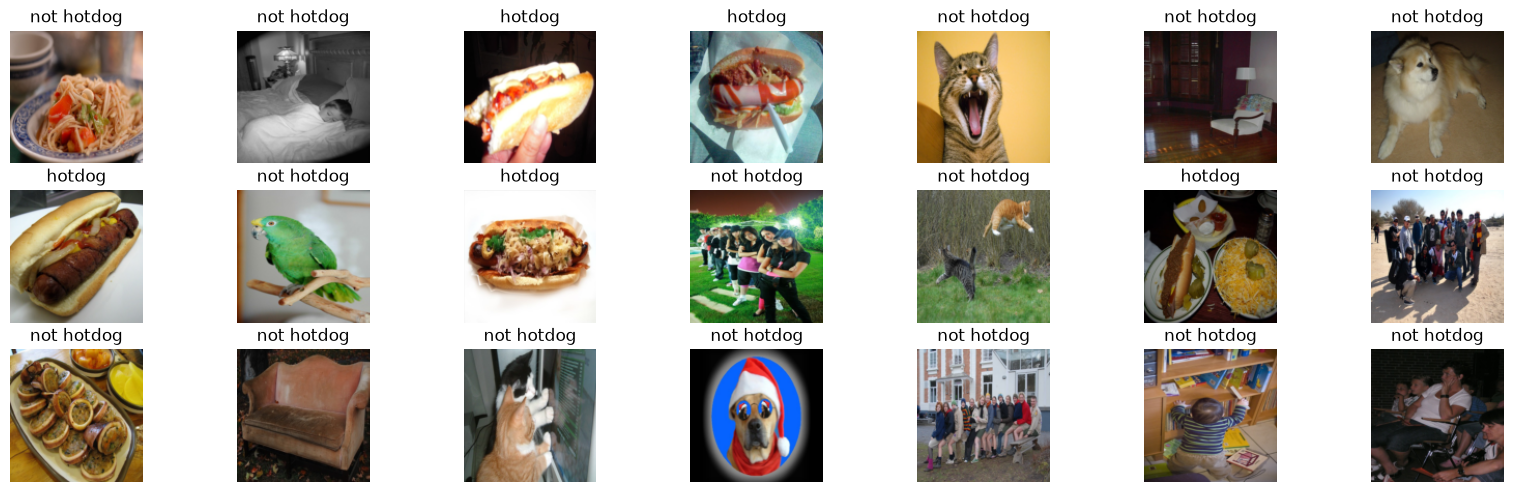

In [5]:
images, labels = next(iter(train_loader))
plt.figure(figsize=(20,10))

mean = np.array([0.485, 0.456, 0.406]).reshape(1, 1, 3)
std = np.array([0.229, 0.224, 0.225]).reshape(1, 1, 3)

for i in range(21):
    plt.subplot(5,7,i+1)
    # Transpose to (H, W, C) and denormalize back to [0, 1] for clean display
    img = np.swapaxes(np.swapaxes(images[i].numpy(), 0, 2), 0, 1)
    img = np.clip(img * std + mean, 0, 1)
    plt.imshow(img)
    plt.title(['hotdog', 'not hotdog'][labels[i].item()])
    plt.axis('off')


Now create a model and train it!


In [6]:
import torch
import torch.nn as nn

# 4 downsampling blocks (32  →  64  →  128  →  256 channels)
class HotdogEfficientCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(HotdogEfficientCNN, self).__init__()
        
        self.features = nn.Sequential(
            # Block 1: 128x128 -> 64x64
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Block 2: 64x64 -> 32x32
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Block 3: 32x32 -> 16x16
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Block 4: 16x16 -> 8x8
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        
        # Global Average Pooling: [B, 256, 8, 8] -> [B, 256, 1, 1]
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        
        # Lightweight classifier head
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

/Users/kkhomefolder/Downloads/semester5-lab/deep-learning-cv/projects/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total Model Parameters: 389,890
Training on device: mps


Epoch  1/15 | Train Loss: 0.6050 | Train Acc: 68.98% | Test Loss: 0.7073 | Test Acc: 50.11%


Epoch  2/15 | Train Loss: 0.5241 | Train Acc: 75.72% | Test Loss: 0.5618 | Test Acc: 72.93%


Epoch  3/15 | Train Loss: 0.4850 | Train Acc: 77.33% | Test Loss: 1.2378 | Test Acc: 54.14%


...

Epoch 11/15 | Train Loss: 0.3888 | Train Acc: 82.80% | Test Loss: 0.4830 | Test Acc: 76.85%


Epoch 12/15 | Train Loss: 0.3684 | Train Acc: 85.00% | Test Loss: 0.5362 | Test Acc: 73.58%


Epoch 13/15 | Train Loss: 0.3648 | Train Acc: 84.66% | Test Loss: 0.6011 | Test Acc: 69.98%


Epoch 14/15 | Train Loss: 0.3770 | Train Acc: 84.27% | Test Loss: 0.7821 | Test Acc: 68.96%


Epoch 15/15 | Train Loss: 0.3598 | Train Acc: 85.93% | Test Loss: 0.6659 | Test Acc: 71.00%


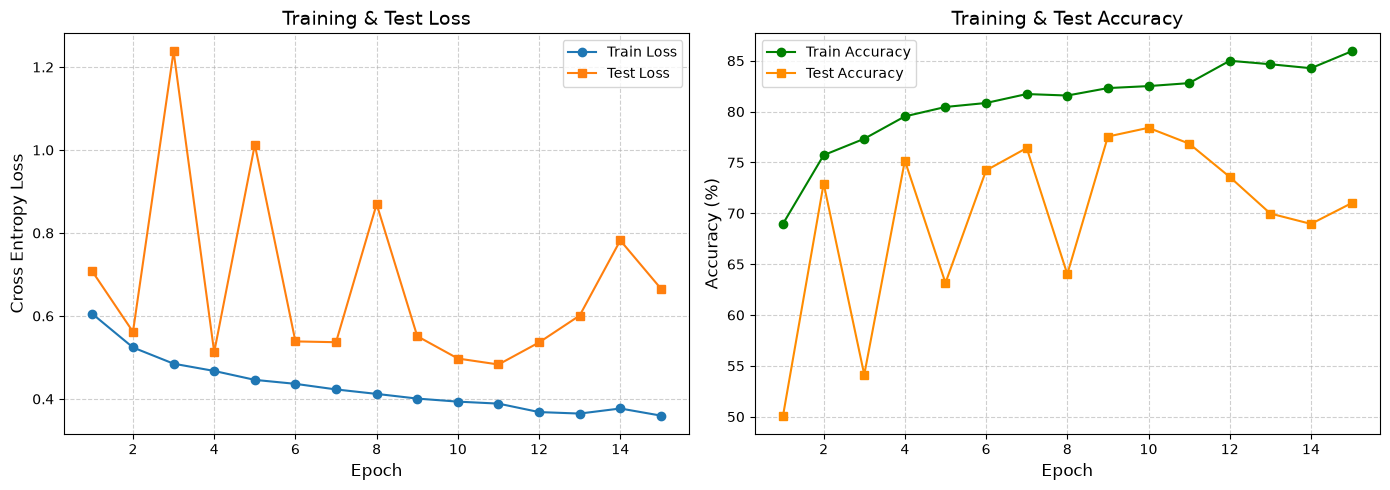

In [8]:
# Ensure robust tqdm import
try:
    from tqdm.auto import tqdm
except Exception:
    from tqdm import tqdm

# ==========================================
# CELL 12: Model Setup, Training & Evaluation Loop
# ==========================================

# 0. Device configuration (CUDA / Apple Silicon MPS / CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')

# 1. Instantiate model and send to device
model = HotdogEfficientCNN(num_classes=2).to(device)

# 2. Loss function & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# 3. Training parameters
num_epochs = 15
history = {
    'train_loss': [], 'train_acc': [],
    'test_loss': [],  'test_acc': []
}

print(f"Total Model Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Training on device: {device}\n" + "=" * 60)

for epoch in range(1, num_epochs + 1):
    # ------------------ TRAINING PHASE ------------------
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs} [Train]", leave=False):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)
        
    epoch_train_loss = running_loss / total_train
    epoch_train_acc = (correct_train / total_train) * 100
    
    # ----------------- VALIDATION PHASE -----------------
    model.eval()
    val_loss, correct_test, total_test = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_test += (preds == labels).sum().item()
            total_test += labels.size(0)
            
    epoch_test_loss = val_loss / total_test
    epoch_test_acc = (correct_test / total_test) * 100
    
    # Record history
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['test_loss'].append(epoch_test_loss)
    history['test_acc'].append(epoch_test_acc)
    
    print(f"Epoch {epoch:2d}/{num_epochs:2d} | "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | "
          f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.2f}%")

# ==========================================
# 4. Plot Loss and Accuracy Learning Curves
# ==========================================
epochs_range = range(1, num_epochs + 1)
plt.figure(figsize=(14, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
plt.plot(epochs_range, history['test_loss'], label='Test Loss', marker='s')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Cross Entropy Loss', fontsize=12)
plt.title('Training & Test Loss', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], label='Train Accuracy', marker='o', color='green')
plt.plot(epochs_range, history['test_acc'], label='Test Accuracy', marker='s', color='darkorange')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Training & Test Accuracy', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

### Baseline Model Evaluation & Observations (Run 1: Custom CNN without Augmentation)

#### 1. Configuration Summary
* **Architecture**: Custom `HotdogEfficientCNN` (4 Conv blocks, BatchNorm2d, Global Average Pooling, Dropout 0.3)
* **Total Parameters**: 389,890
* **Input Resolution**: $128 \times 128$ (direct resize, un-normalized)
* **Optimizer**: Adam ($\text{lr} = 10^{-3}$, $\text{weight decay} = 10^{-4}$)
* **Epochs**: 15

---

#### 2. Key Results
* **Best Test Accuracy**: **78.41%** (Epoch 10)
* **Lowest Test Loss**: **0.4830** (Epoch 11)
* **Final Epoch 15**: Train Acc: **85.93%** / Test Acc: **71.00%** (Train Loss: 0.3598 / Test Loss: 0.6659)

---

#### 3. Analysis & Diagnosis for Report

1. **Clear Emergence of Overfitting**:
   * Up to **Epoch 10–11**, both train and test metrics improve together (test accuracy climbs from $50.11\%$ to $78.41\%$).
   * From **Epoch 11 to 15**, training accuracy continues to rise ($82.8\% \to 85.9\%$), but test loss sharply degrades ($0.4830 \to 0.6659$) and test accuracy drops from $78.41\%$ to $71.00\%$. The network is beginning to memorize the raw training images.

2. **Validation Volatility**:
   * The test loss displays sharp spikes across epochs (e.g., jumping from $0.56$ in Epoch 2 to $1.24$ in Epoch 3, and $0.51$ in Epoch 4 to $1.01$ in Epoch 5). 
   * This instability suggests that without input normalization and data augmentation, the optimization landscape is sensitive to batch variance and individual outlier images.

---

#### 4. Hypothesis & Next Steps
* **Hypothesis 1 (Data Augmentation)**: Introducing random horizontal flips, mild rotations ($\pm 15^\circ$), and color jitter will act as a regularizer, preventing the model from memorizing specific orientations and reducing the train/test generalization gap after epoch 10.
* **Hypothesis 2 (Standard Normalization)**: Applying standard ImageNet channel normalization will center the input distribution around zero, helping reduce the test loss volatility across epochs.
* **Hypothesis 3 (Learning Rate Decay / Early Stopping)**: Reducing the learning rate after epoch 8–10 or stopping around epoch 10 will preserve the peak checkpoint ($~78.4\%$).
